<a href="https://colab.research.google.com/github/isamattar/FIAP-Data-Science/blob/main/Exerc%C3%ADcio_s%C3%A9ries_temporais_RM562481.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

#link "RAW"
url = "https://raw.githubusercontent.com/diogenesjusto/FIAP/refs/heads/master/Gradua%C3%A7%C3%A3o/dados/base_transacional_supermercado.csv"

df = pd.read_csv(url)

df.head()

,PARTNER_ID,CUSTOMER_ID,CodFamilia,PRODUCT_ID,STORE_ID,AMOUNT,DATE,DISCOUNT_AMOUNT,DISPLAY_FLAG,FEATURE_FLAG,GROSS_PROFIT_AMOUNT,POINTS_BONUS_AMOUNT,QUANTITY,CATEGORY_1,CATEGORY_2,CATEGORY_3,CATEGORY_4,NAME
0,1160653,95595791691,138104,196282,409,8.98,2020-01-01 00:14:41 UTC,0.0,0,0,3.875962,40,2.0,MERCEARIA,BOMBONIERE SECAO,BOMBONS-CHOCOLATES,CHOC BARRA-TABLETE,CHOC GAROTO 90G-TA CAST CAJU
1,1160653,8814812624,97760,136956,62,0.00,2020-01-01 00:10:16 UTC,0.0,0,0,-60.099320,120,4.0,MERCEARIA,BEBIDAS,VINHOS,VIN CHILENO,VIN CHIL ANTAKARI RSV 750ML CHARD
2,1160653,38552620634,247,329,408,9.98,2020-01-01 00:08:29 UTC,0.0,0,0,2.965819,20,1.0,MERCEARIA,MATINAIS SECAO,CAFES,CAFE CAPPUCINO-COM LEITE,CAPPUCCINO 3CORACOES CLAS 200G-PT
3,1160653,11561694614,77004,104089,405,7.99,2020-01-01 00:06:10 UTC,0.0,0,0,1.807759,20,1.0,MERCEARIA,CONSERVAS-CONDIMENTOS,CONDIMENTOS-TEMPEROS,CATCHUP FR ATE 500G,KETCHUP HEINZ 397G-PET TRAD
4,1160653,1216506698,138045,196180,62,11.96,2020-01-01 00:05:30 UTC,0.0,0,0,3.739260,30,2.0,PERECIVEIS,P.A.S.,VEGETAIS CONG,LEGUME CONG,ANEIS CEBOLA GOLDEN FOODS 350G-PC


Sucesso! Arquivo carregado.


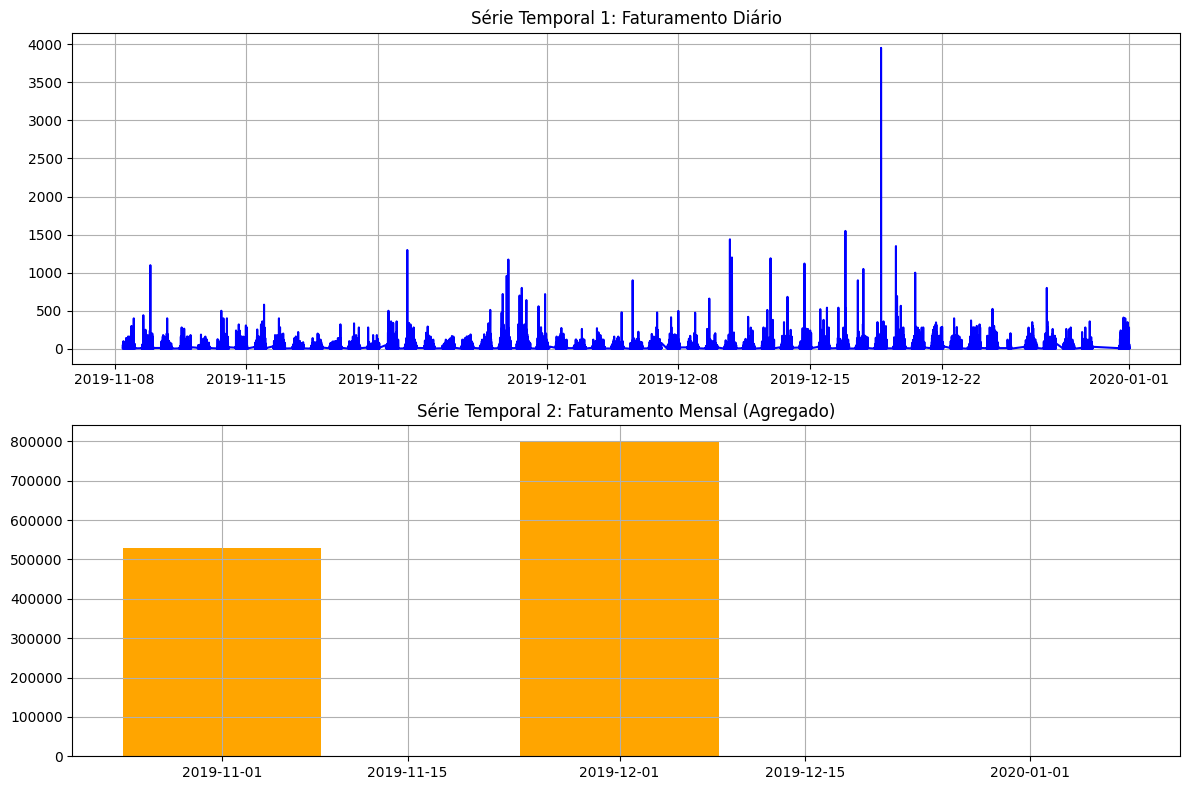


--- SÉRIES TEMPORAIS IDENTIFICADAS ---
                       DATE     AMOUNT
0 2019-11-01 00:00:00+00:00  529449.52
1 2019-12-01 00:00:00+00:00  800646.87
2 2020-01-01 00:00:00+00:00      66.71


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/diogenesjusto/FIAP/refs/heads/master/Gradua%C3%A7%C3%A3o/dados/base_transacional_supermercado.csv"

try:
    df = pd.read_csv(url)
    print("Sucesso! Arquivo carregado.")
except:
    print("Erro ao carregar.")

df['DATE'] = pd.to_datetime(df['DATE'])

serie_diaria = df.groupby('DATE')['AMOUNT'].sum().reset_index()

serie_mensal = df.resample('MS', on='DATE')['AMOUNT'].sum().reset_index()

plt.figure(figsize=(12, 8))

# Gráfico Diário
plt.subplot(2, 1, 1)
plt.plot(serie_diaria['DATE'], serie_diaria['AMOUNT'], color='blue')
plt.title('Série Temporal 1: Faturamento Diário')
plt.grid(True)

# Gráfico Mensal
plt.subplot(2, 1, 2)
plt.bar(serie_mensal['DATE'], serie_mensal['AMOUNT'], width=15, color='orange')
plt.title('Série Temporal 2: Faturamento Mensal (Agregado)')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n--- SÉRIES TEMPORAIS IDENTIFICADAS ---")
print(serie_mensal)